# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA 모델 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)로, 아래 코드를 통해 간단하게 불러올 수 있습니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("smid80/weatherww2")

print("Path to dataset files:", path)

100%|██████████| 1.65M/1.65M [00:00<00:00, 2.77MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/smid80/weatherww2/versions/1


In [2]:
# kaggle 데이터 로드
import os

# path = "/root/.cache/kagglehub/datasets/smid80/weatherww2/versions/1"

print(os.listdir(path))

['Summary of Weather.csv', 'Weather Station Locations.csv']


In [4]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_file_path = os.path.join(path, "Weather Station Locations.csv")
loc_df = pd.read_csv(loc_file_path)
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [5]:
# station별 실제 날씨 데이터
weather_file_path = os.path.join(path, "Summary of Weather.csv")
weather_df = pd.read_csv(weather_file_path)

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_10161/3677884962.py:3: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv(weather_file_path)


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [ ]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_2134/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_2134/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


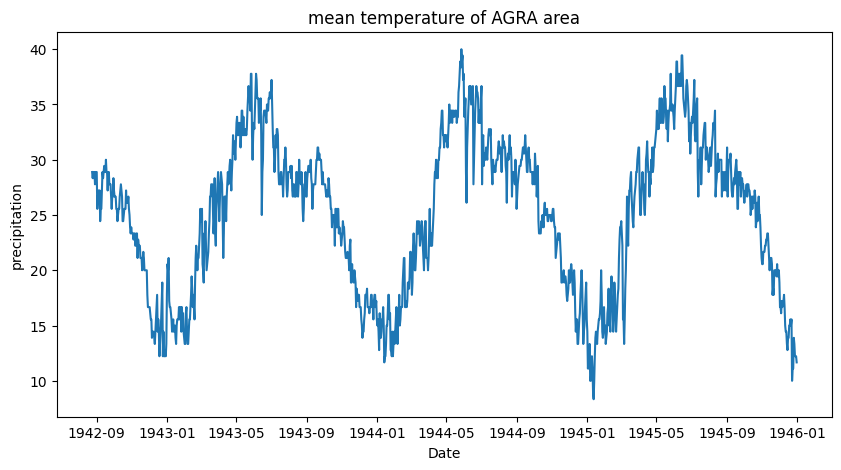

In [ ]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [ ]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

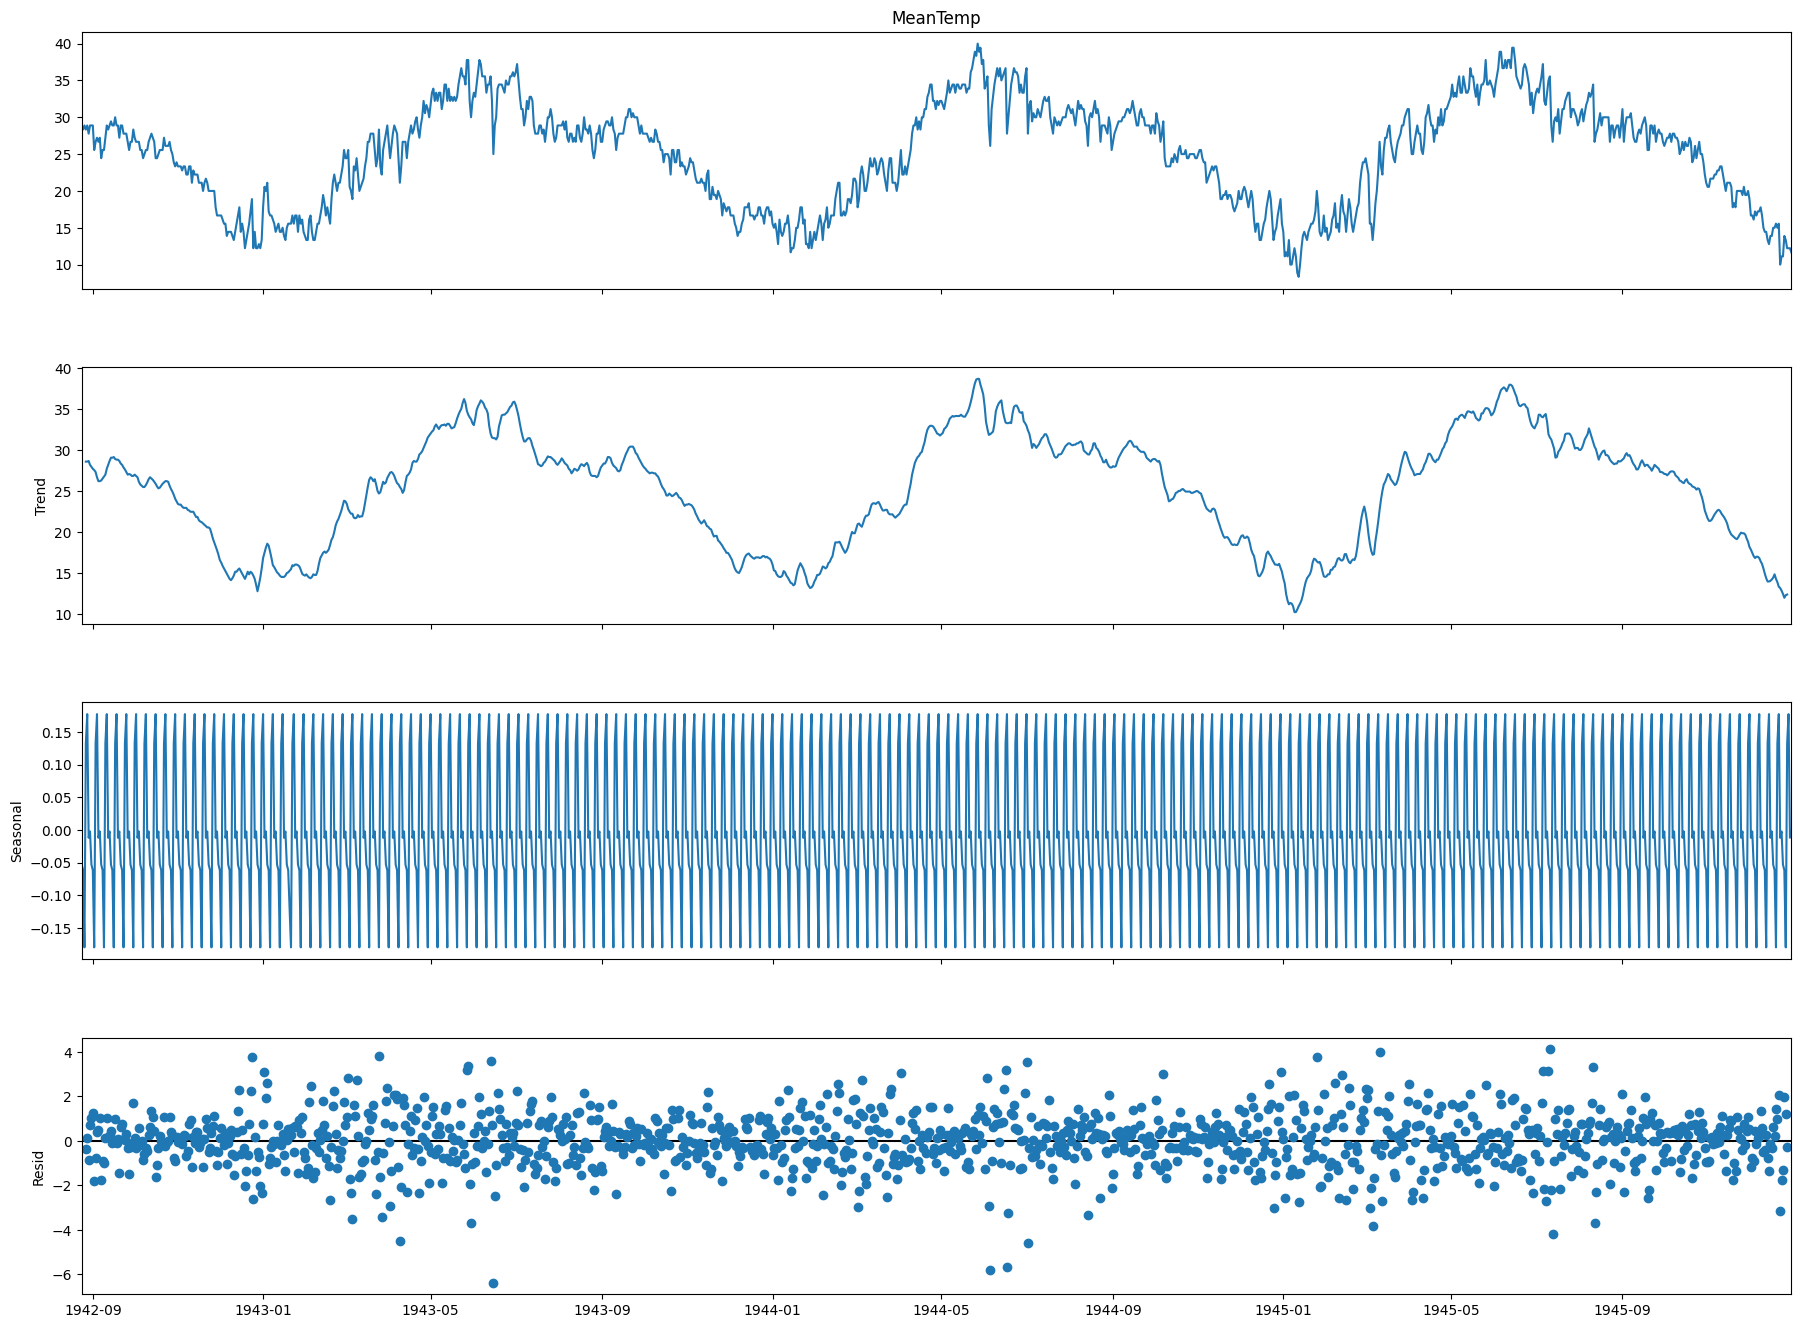

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

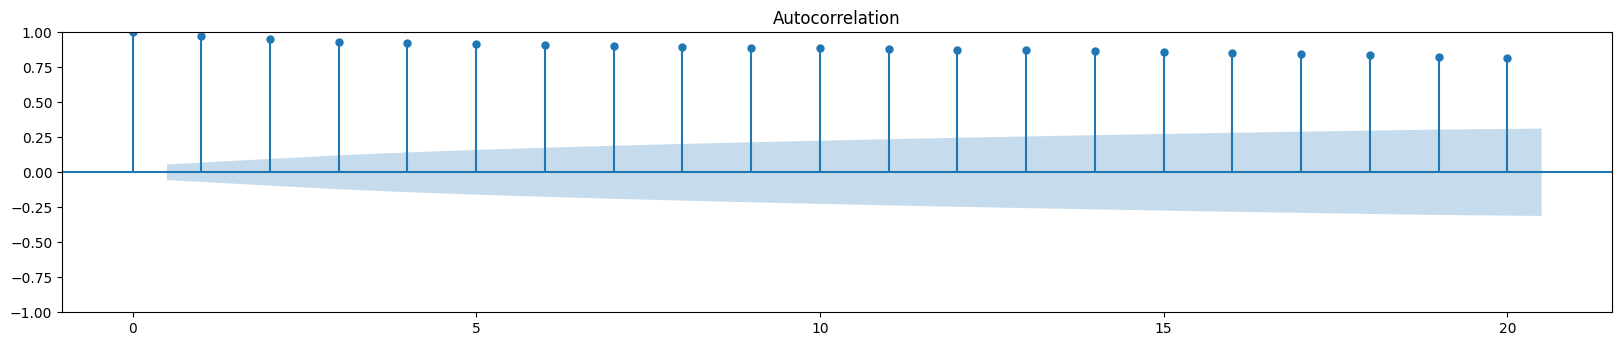

In [ ]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.

A1.  
- 귀무가설은 "ARGA 지역의 온도가 비정상 시계열이다." 혹은  "ARGA 지역의 온도에 단위근이 존재한다."라고 가정한다.
- ADF Test를 통한 검정 결과 p-value가 0.25이므로, 유의수준 0.05에 대해 귀무가설을 기각할 수 없다.
- 따라서 ARGA 지역의 온도는 비정상 시계열이다.

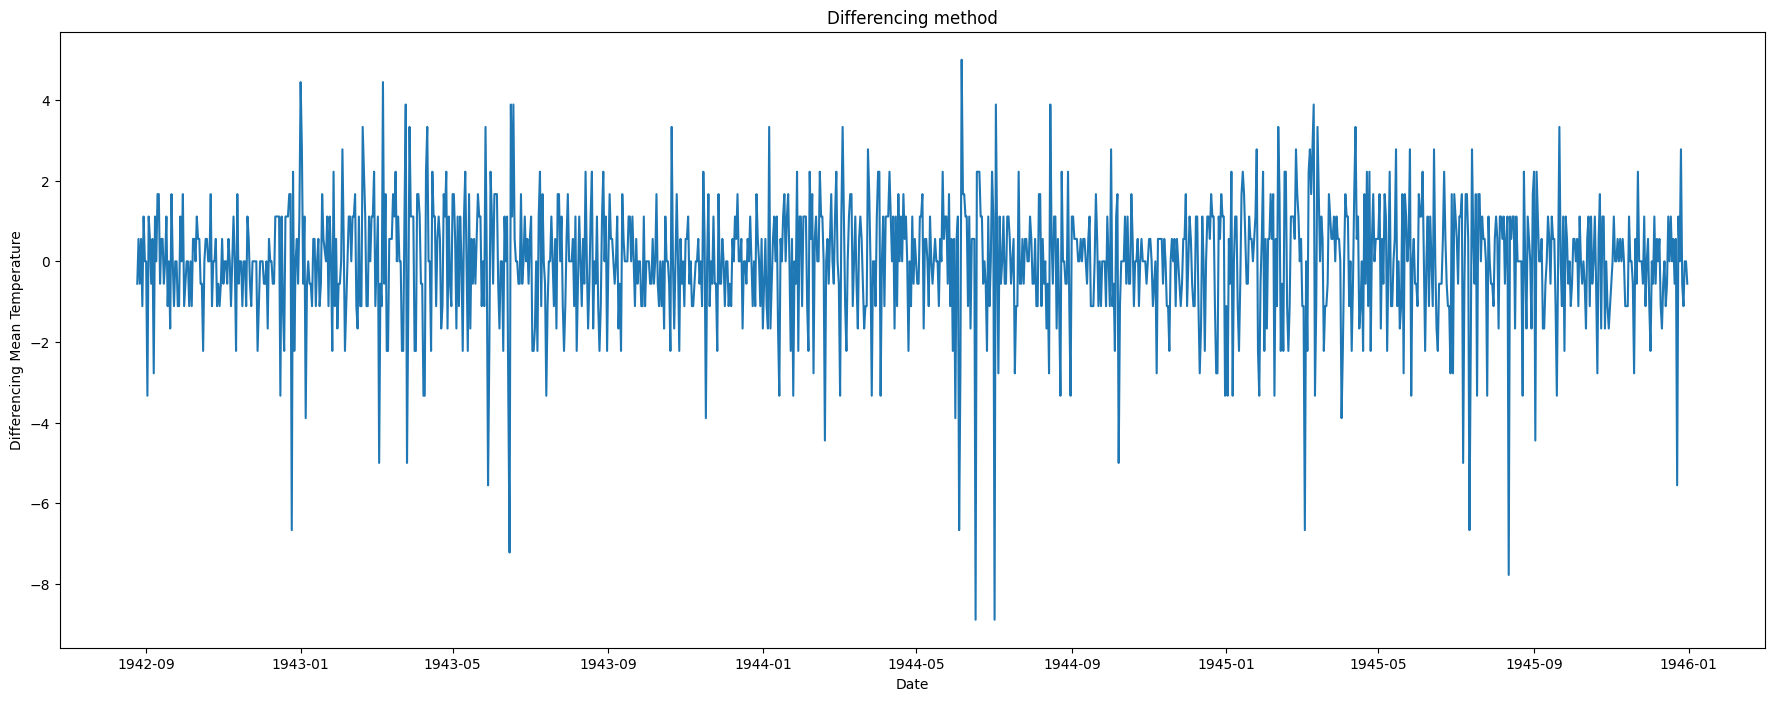

In [ ]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [ ]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2.  
- 이전의 결과와 비교해 ADF Test 결과가 유의하게 나왔고, (1차 차분한 기온이) 비정상 시계열이라는 귀무가설을 기각하여 차분 후에는 정상 시계열이 되었다고 볼 수 있다.
- A1의 분석 대상이었던 기본 기온 데이터에서 1차 차분을 진행했기 때문이다.

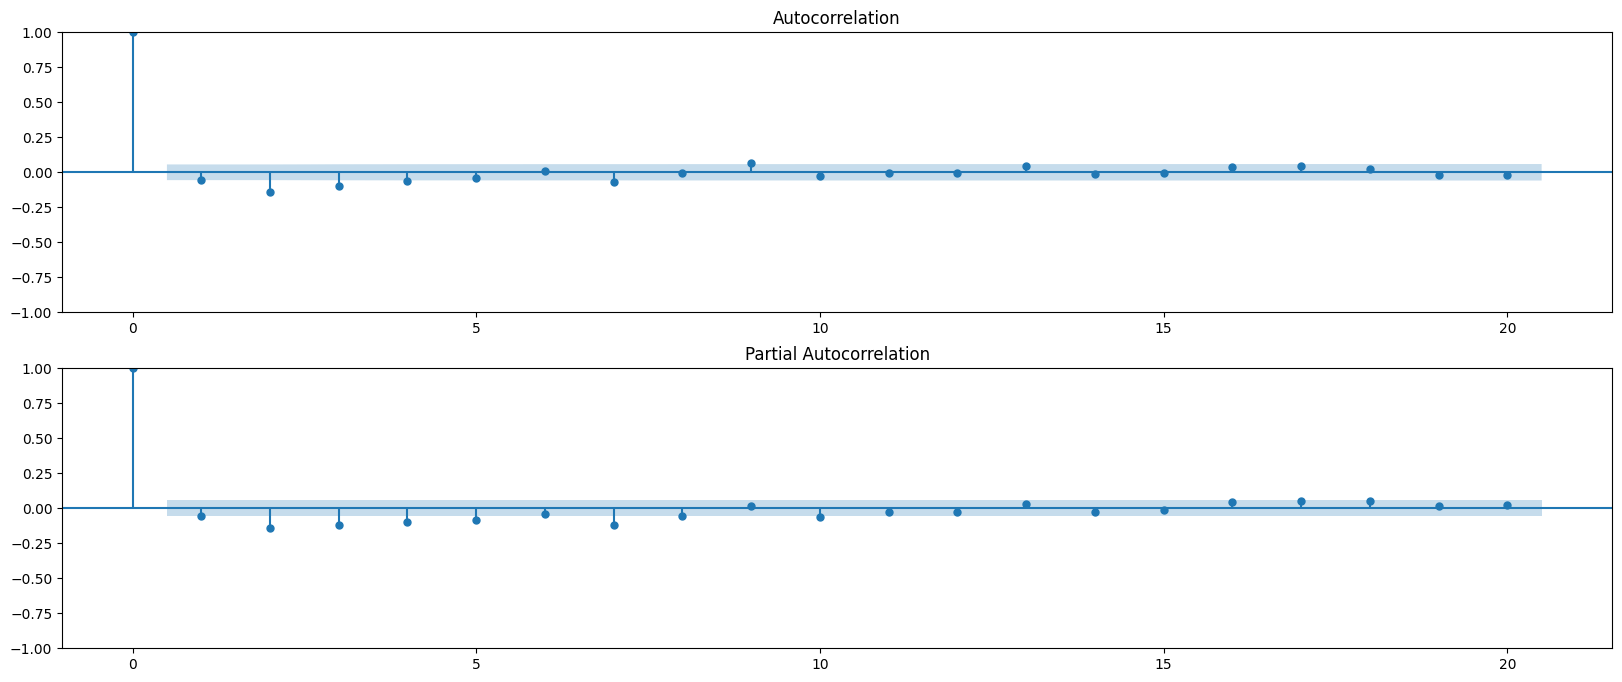

In [ ]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3.  
- 차분된 데이터에 대해 위쪽 그림은 acf를, 아래쪽 그림은 pacf를 나타낸다.
- acf는 $y_t$와 $y_{t+k}$의 상관관계를, pacf는 다른 $y$값의 영향을 배제한 채 $y_{t}$와 $y_{t+k}$의 상관관계를 측정하는 것이다.
- 주로 acf가 절단되는 시점 직전으로 q를, pacf가 0에 절단되는 시점 직전으로 p를 결정한다.
- p=1, q=1이다.

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


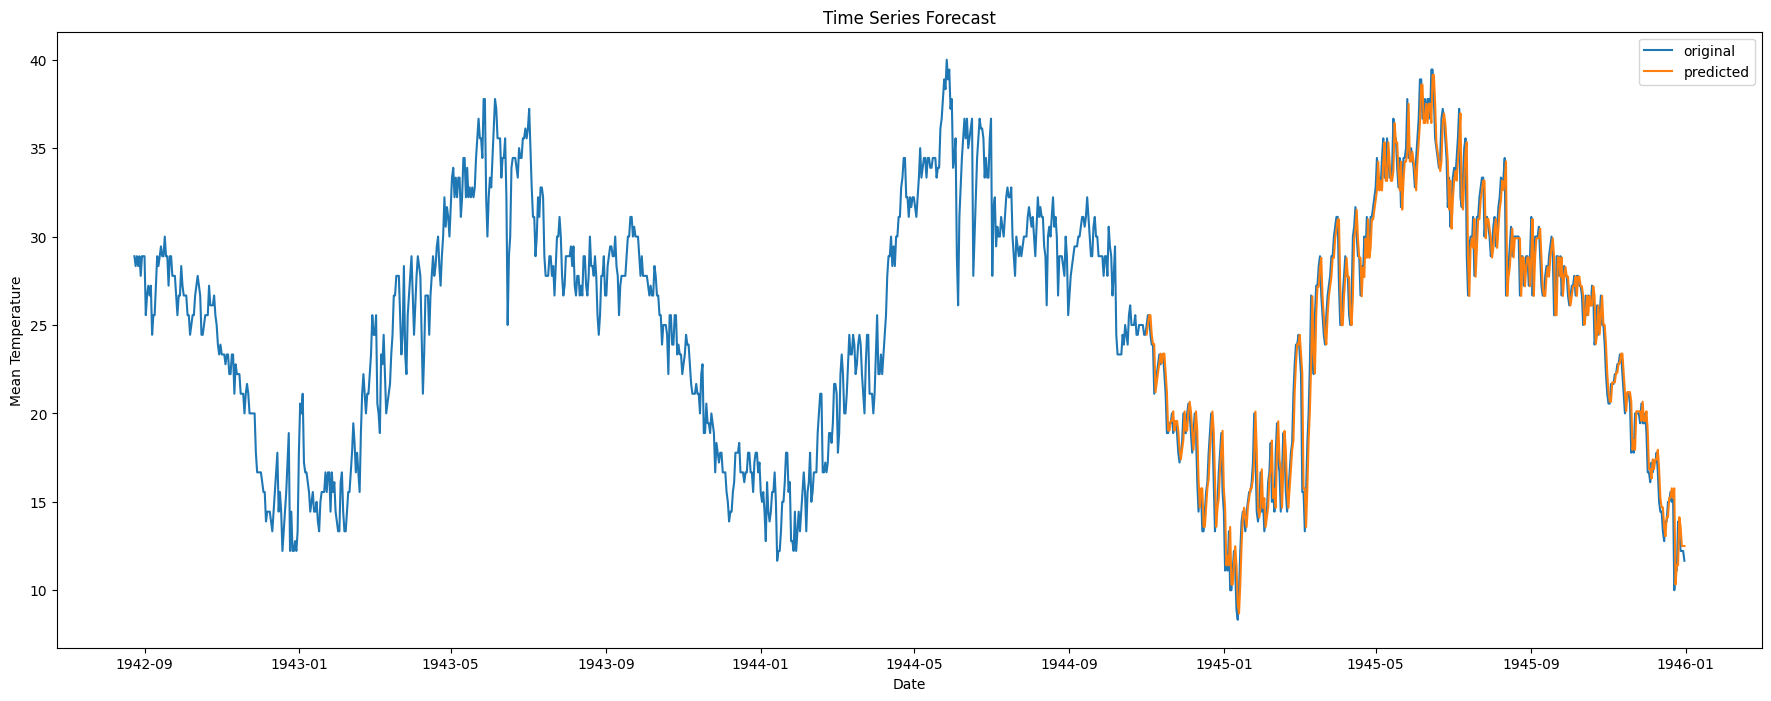

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 1
d = 1
q = 1

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_2134/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


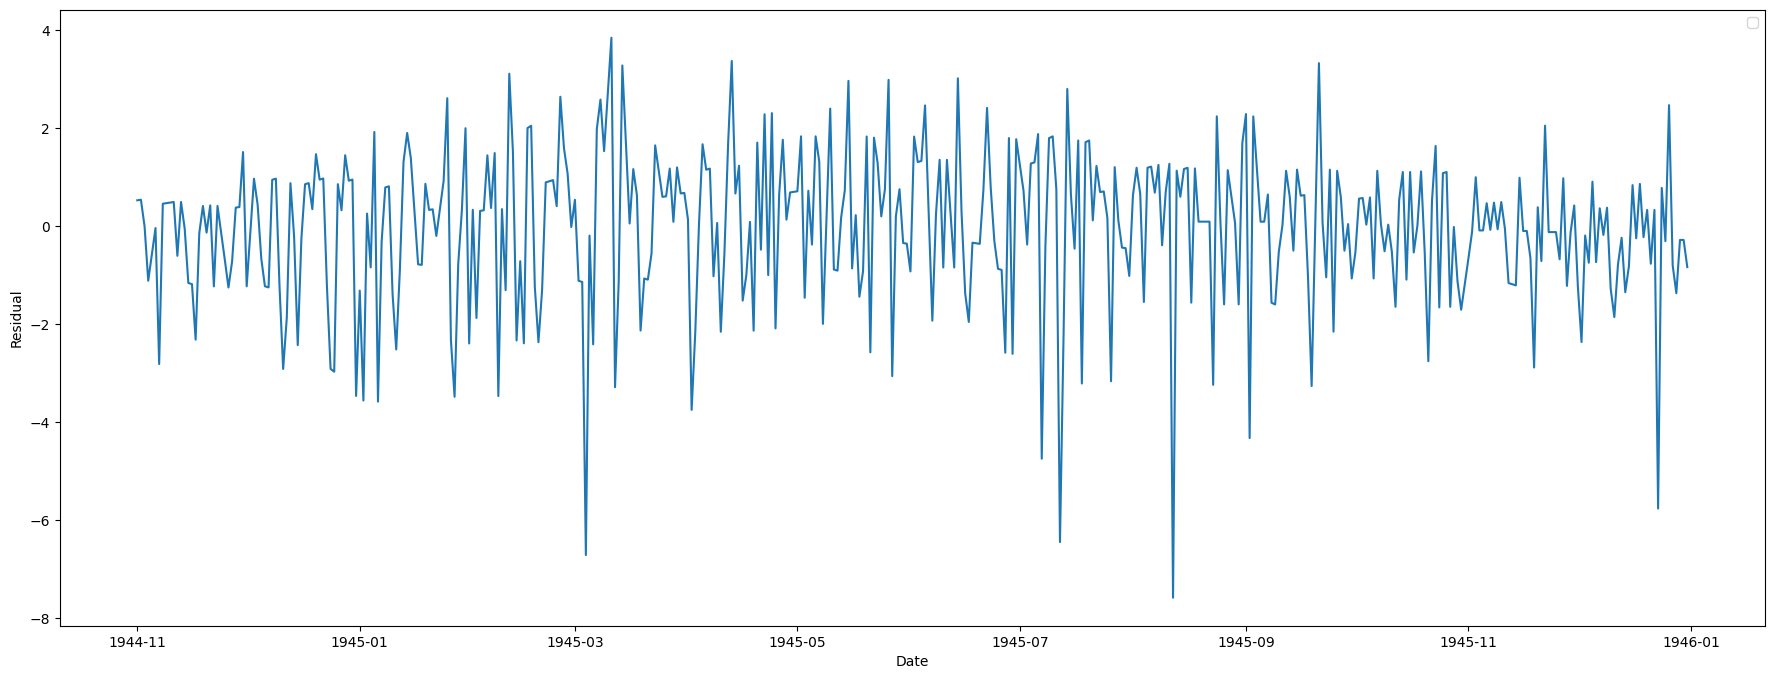

In [ ]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

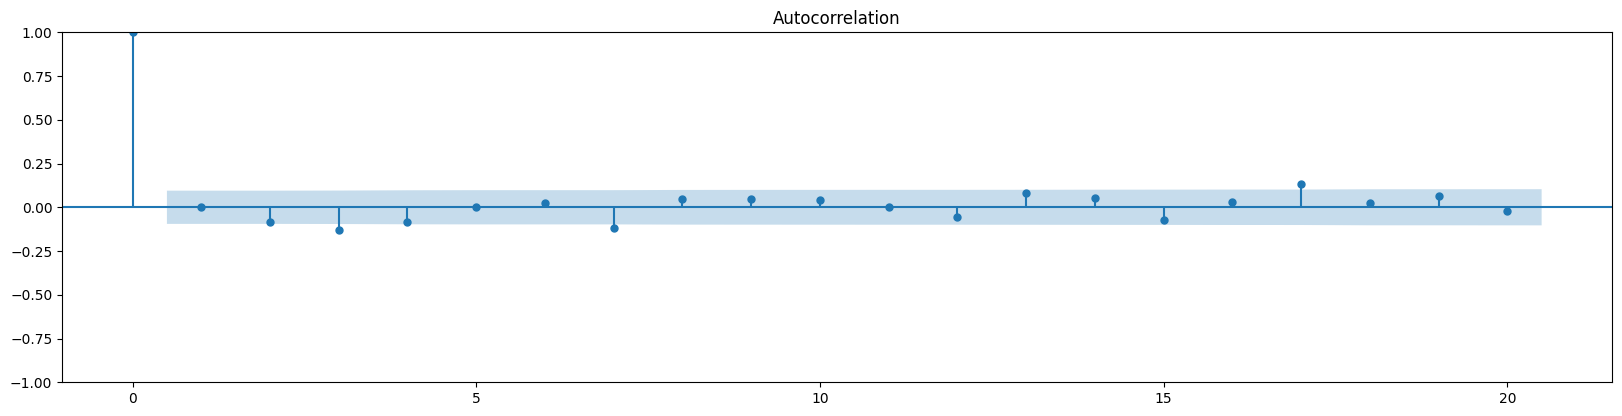

In [ ]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [ ]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.899484
p-value: 0.002039
Critical Values:
	1%: -3.446
	5%: -2.869
	10%: -2.571


In [ ]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [ ]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.589,0.978,1.56,5.426


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4.  
- ARIMA(1,1,1)을 거친 이후 잔차 분석은 ADF-Test를 통해 정상성을 만족함을 확인할 수 있다.
- R2값은 모델의 설명력으로 ARIMA모델이 95%의 설명력을 보인다는 것을 알 수 있고, Corr을 통해 예측값과 실제값이 양의 선형 관계를 띰을 알 수 있다.
- 온도의 스케일 범위가 10~40인 걸 감안할 때, RMSE, MAPE라 각각 1.5, 5.2인 것은 괜찮은 성능을 보인다고 해석할 수 있다.

### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4.

In [48]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [49]:
train_ts = ts[ts.index < start_index]
test_ts = ts[ts.index >= start_index]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_ts)
test_scaled = scaler.transform(test_ts)

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by MinMaxScaler.

In [ ]:
seq_len = 365 # 입력 길이
pred_len = len(test_scaled) # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len + 1

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [ ]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=365):
    super(DLinear, self).__init__()

    self.seq_len = seq_len
    self.pred_len = pred_len

    self.moving_avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=kernel_size//2)

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)  # (B,1,L)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)

    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)

    seasonal_out = self.linear_seasonal(seasonal)
    trend_out = self.linear_trend(trend)

    return seasonal_out + trend_out

In [ ]:
model = DLinear(
    seq_len=seq_len,
    pred_len=pred_len,
    kernel_size=365
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 10

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.841781


In [ ]:
model.eval()

x = torch.tensor(train_scaled[-seq_len:], dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
  pred = model(x).cpu().numpy()

forecast_dl = scaler.inverse_transform(pred.reshape(-1,1))

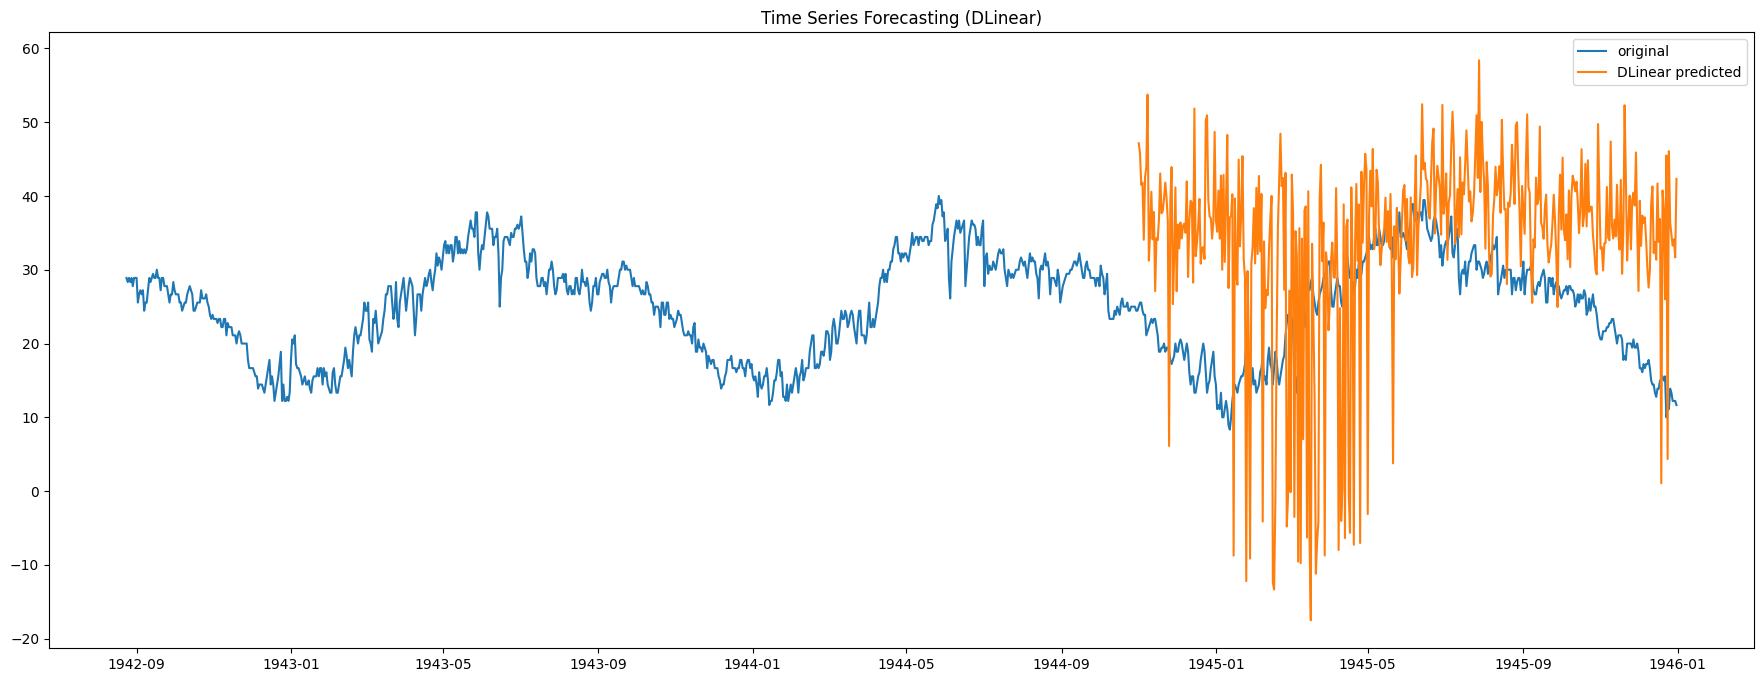

In [ ]:
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(test_ts.index, forecast_dl, label="DLinear predicted")
plt.title("Time Series Forecasting (DLinear)")
plt.legend()
plt.show()

In [ ]:
scoring(
  np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp),
  forecast_dl.flatten()
)

,R2,Corr,RMSE,MAPE
0,-433.028,0.114,17.149,74.855


## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
AMBERLY,848
AMURI/FIELD AAF,884
ATAR,876
...,...
TINDOUF,818
VAL DE CANS,1188
WALLER/BWI,1631


### 1. 데이터 전처리

In [7]:
weather_df = pd.read_csv(weather_file_path)
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  object 
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-

/tmp/ipykernel_10161/281203855.py:1: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv(weather_file_path)


In [9]:
# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "Precip"]] # 강수량 데이터 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "Precip"]] # 강수량 데이터

weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")
weather_df.head()

# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "ACCRA"].WBAN #ACCRA 지역
weather_bin = weather_df[weather_df.STA == int(loc_sta.iloc[0])]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_10161/49892034.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,Precip
0,10001,1942-07-01,1.016
1,10001,1942-07-02,0.000
2,10001,1942-07-03,2.540
3,10001,1942-07-04,2.540
4,10001,1942-07-05,0.000
...,...,...,...
1152,10001,1945-08-27,0.100
1153,10001,1945-08-28,13.970
1154,10001,1945-08-29,3.048
1155,10001,1945-08-30,0.100


### 2. EDA

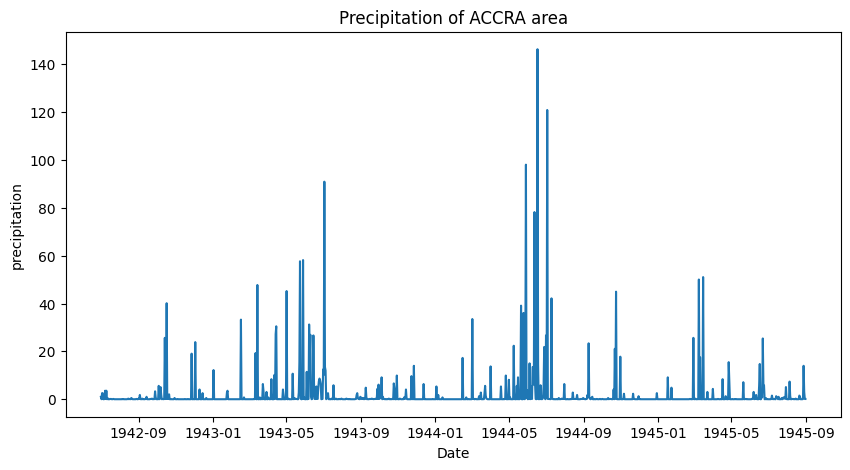

In [11]:
# 해당 지역의 평균 강수량
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.Precip)
plt.title("Precipitation of ACCRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [14]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 25.4 MB/s eta 0:00:00


<Figure size 640x480 with 0 Axes>

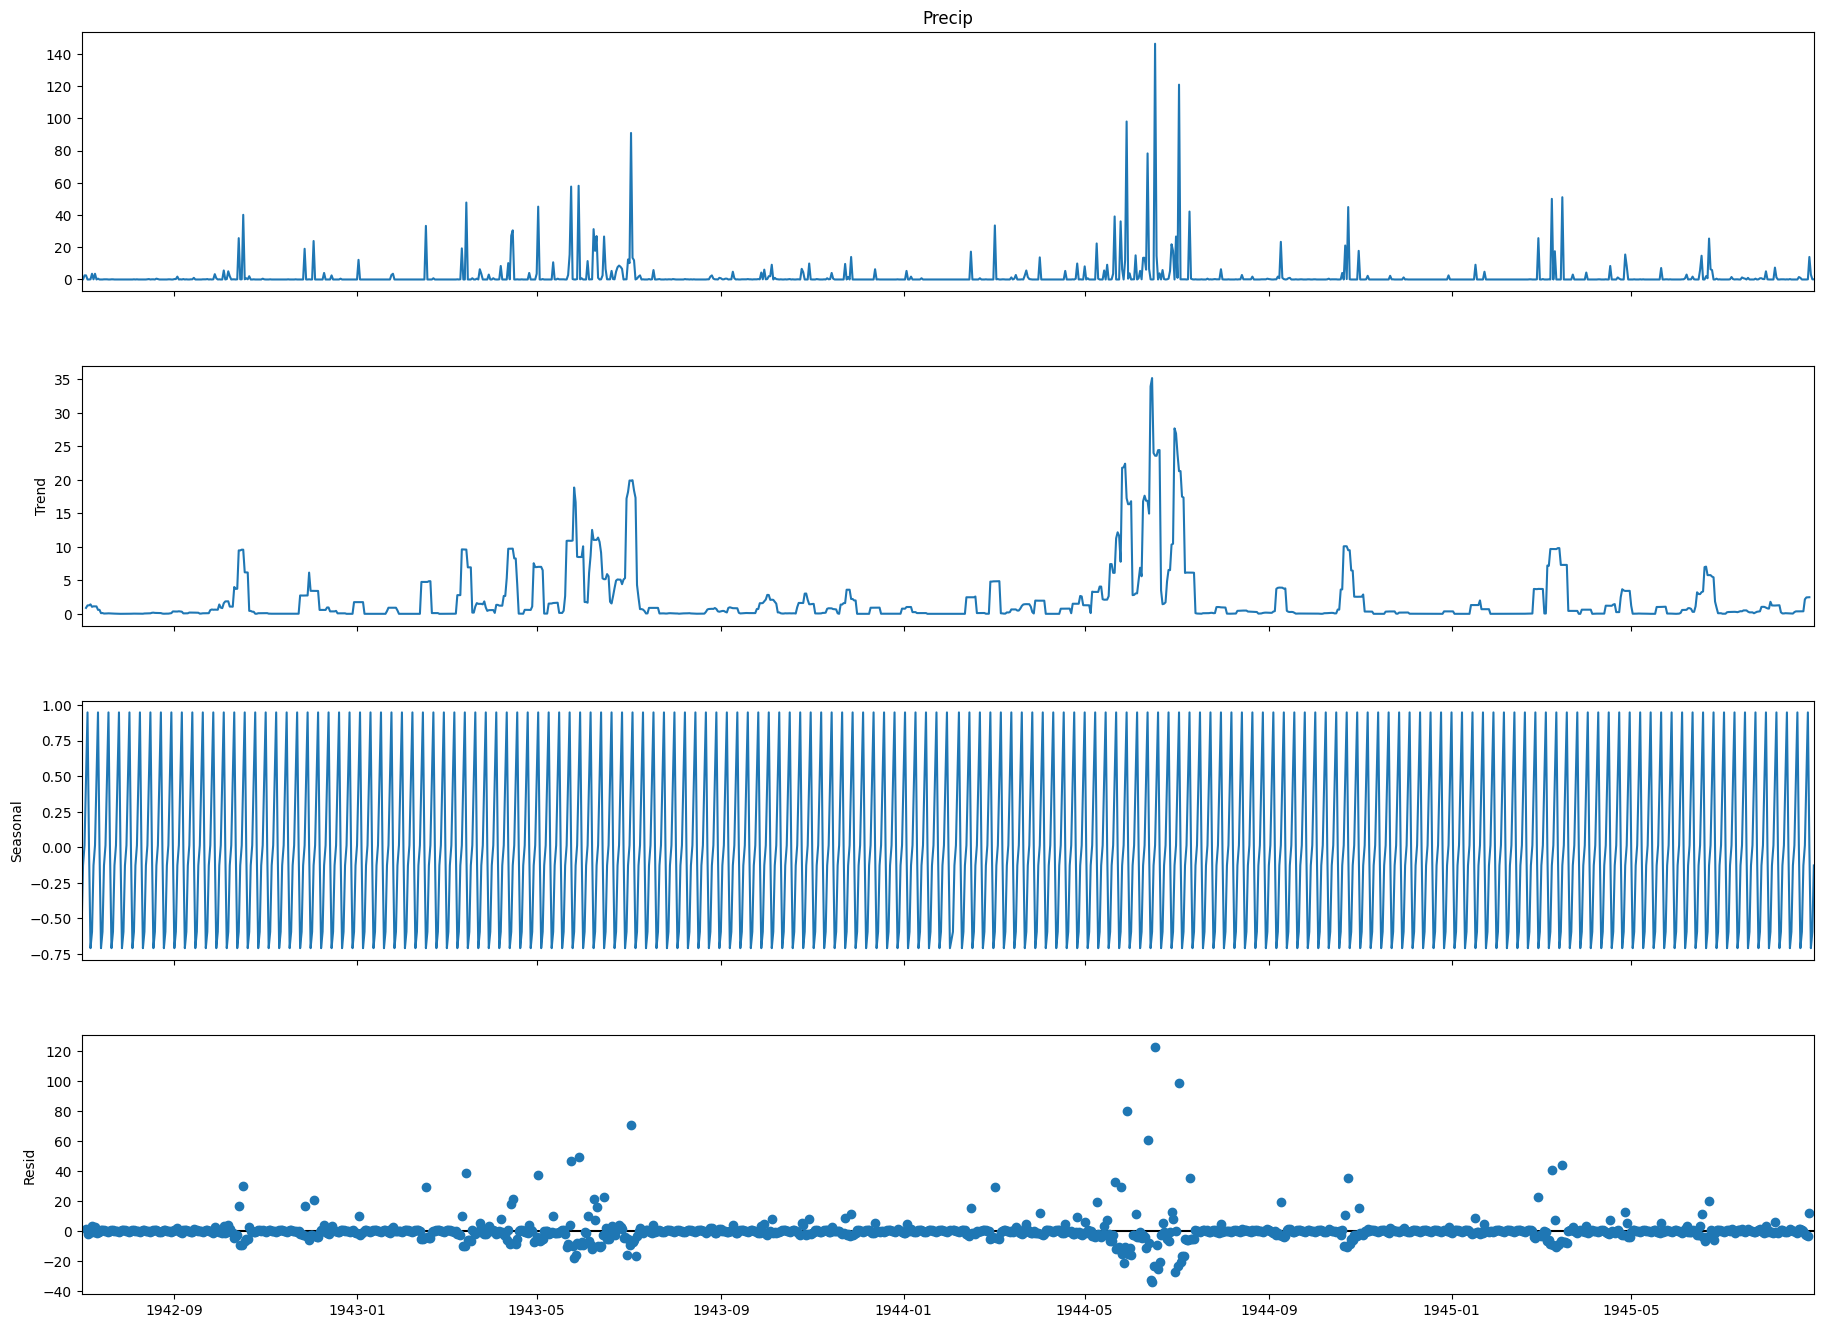

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 데이터 시계열 형태로 변환
timeSeries = weather_bin.loc[:, ["Date", "Precip"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

##
# 시계열 구성요소별 분리
result = seasonal_decompose(ts["Precip"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 3. 정상성 가설검정

ADF Statistic: -3.746492
p-value: 0.003505
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


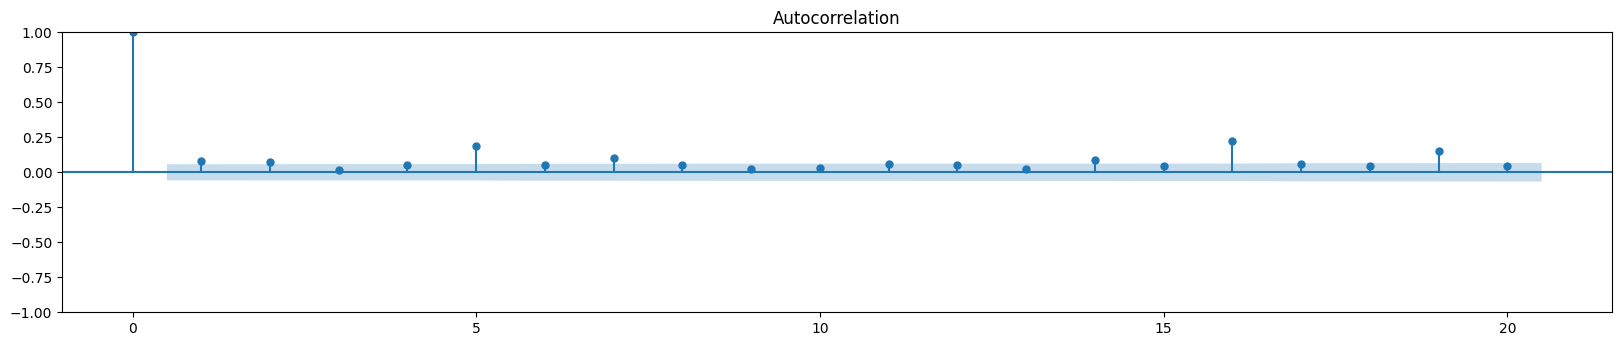

In [16]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

### 4. 차분 후 정상성 가설검정

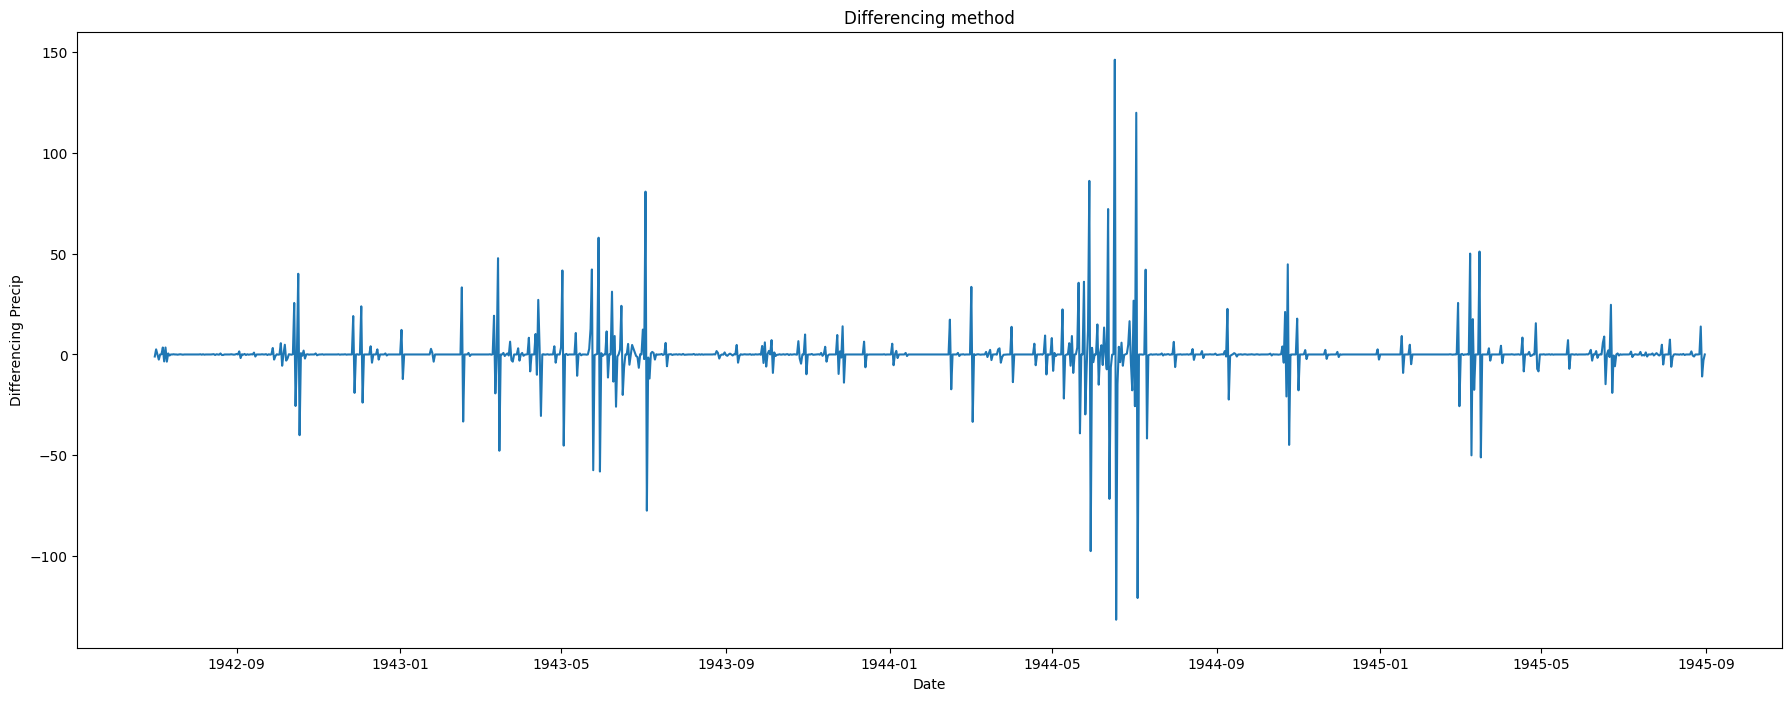

ADF Statistic: -12.020696
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


In [42]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Precip")
plt.show()

result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

### 5. ARIMA 모델 적합

In [43]:
ts

,Precip
Date,
1942-07-01,1.016
1942-07-02,0.000
1942-07-03,2.540
1942-07-04,2.540
1942-07-05,0.000
...,...
1945-08-27,0.100
1945-08-28,13.970
1945-08-29,3.048


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


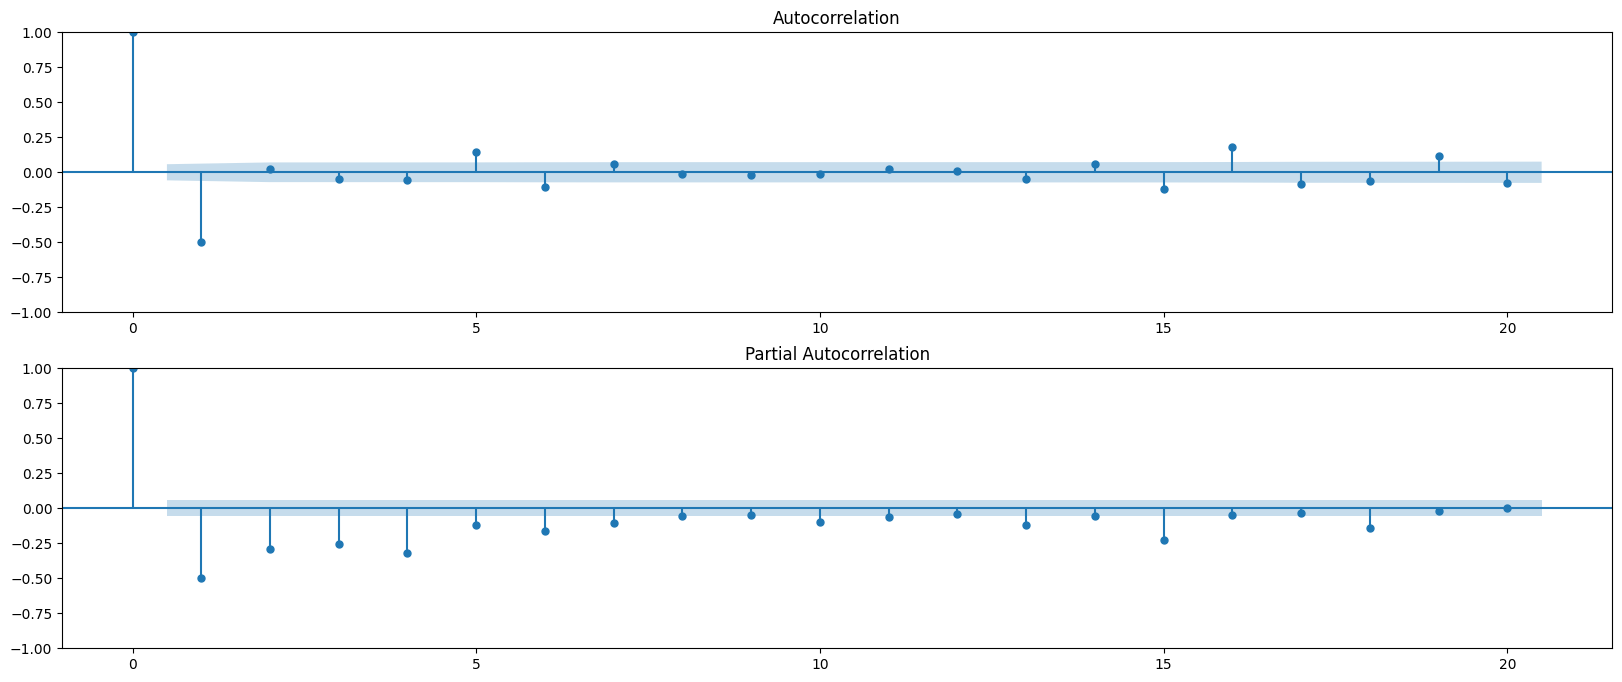

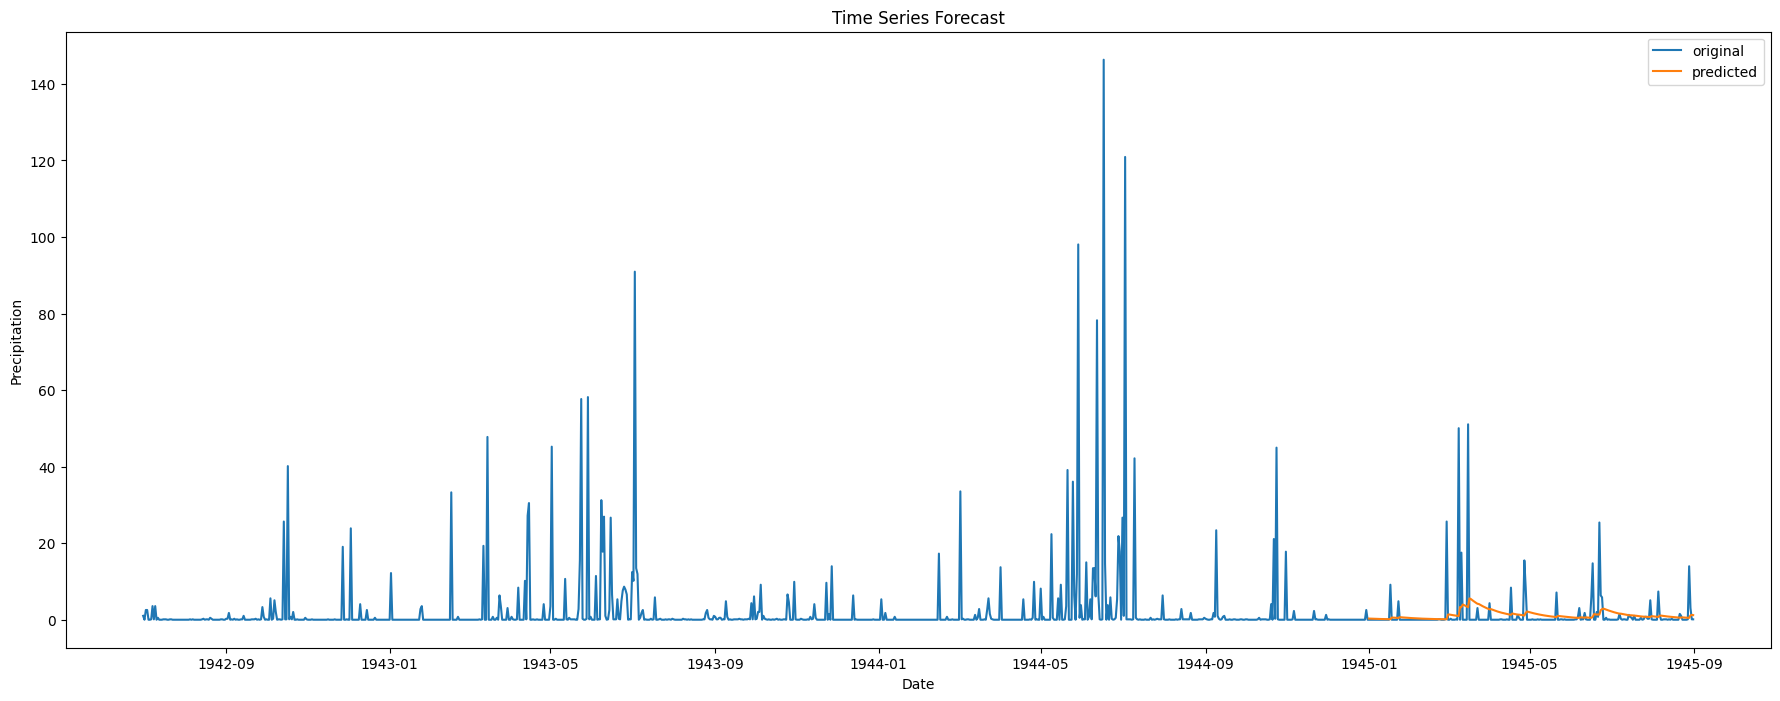

In [67]:
# ACF, PACF 확인
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)
##
# ARIMA 적합
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 1
d = 1
q = 1

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1945, 1, 1)
end_index = datetime(1945, 8, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.Precip, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.legend()
plt.show()

### 6. ARIMA 적합 결과 해석

/tmp/ipykernel_10161/547947738.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


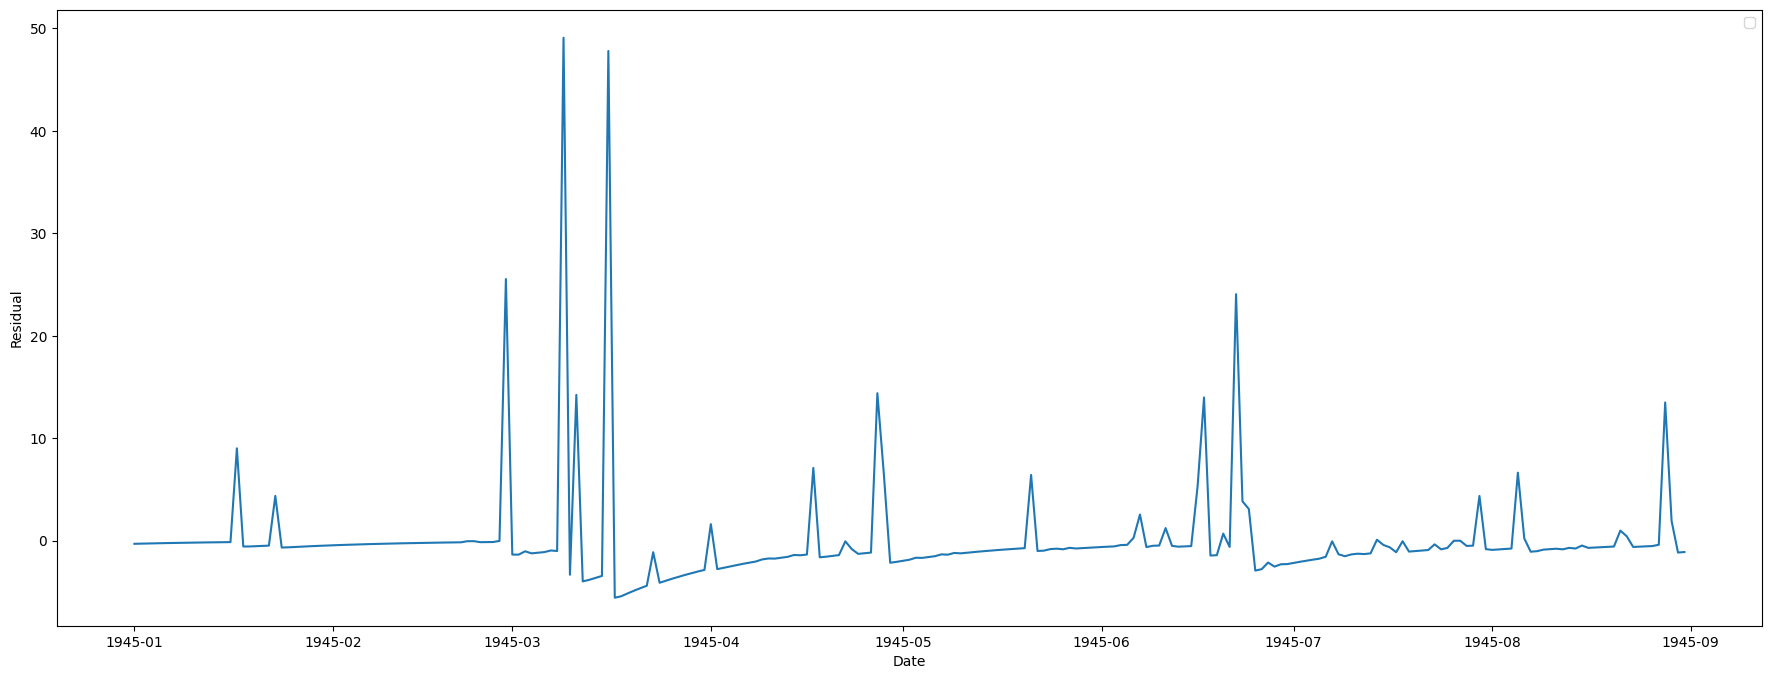

ADF Statistic: -4.337170
p-value: 0.000383
Critical Values:
	1%: -3.459
	5%: -2.874
	10%: -2.574


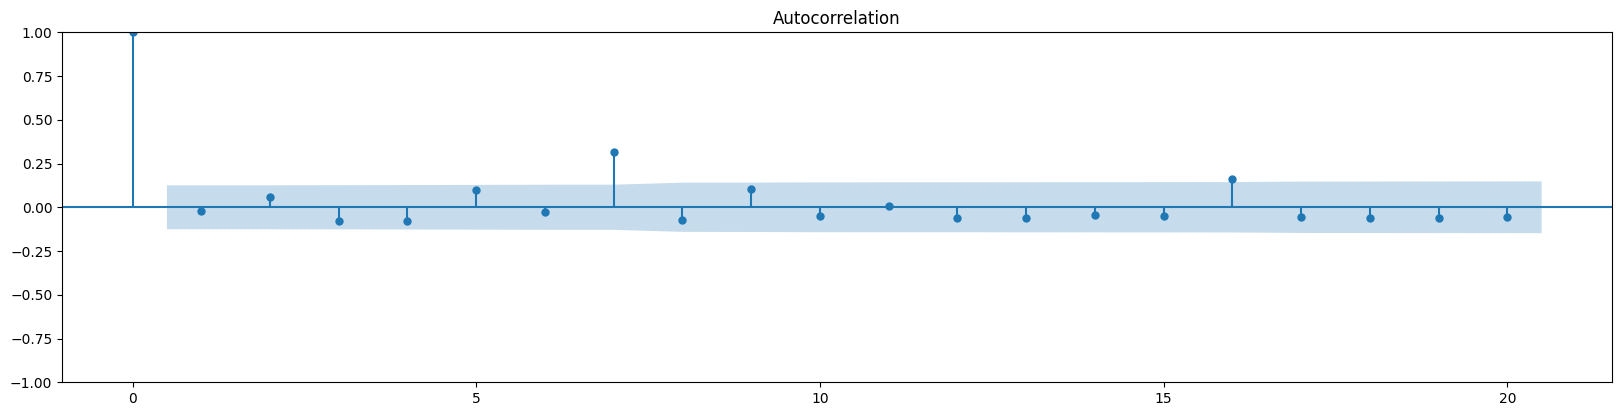

In [68]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].Precip) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

In [69]:
# 예측 결과 확인
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

scoring(np.array(weather_bin[weather_bin.Date >= start_index].Precip), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,-1.655,0.055,5.606,3.966903e+17


### 7. DLinear 적합

In [73]:
train_ts = ts[ts.index < start_index]
test_ts = ts[ts.index >= start_index]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_ts)
test_scaled = scaler.transform(test_ts)
##
seq_len = 365 # 입력 길이
pred_len = len(test_scaled) # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len + 1

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
##
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=365):
    super(DLinear, self).__init__()

    self.seq_len = seq_len
    self.pred_len = pred_len

    self.moving_avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=kernel_size//2)

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)  # (B,1,L)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)

    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)

    seasonal_out = self.linear_seasonal(seasonal)
    trend_out = self.linear_trend(trend)

    return seasonal_out + trend_out
##

model = DLinear(
    seq_len=seq_len,
    pred_len=pred_len,
    kernel_size=365
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 100

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")
##
model.eval()

x = torch.tensor(train_scaled[-seq_len:], dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
  pred = model(x).cpu().numpy()

forecast_dl = scaler.inverse_transform(pred.reshape(-1,1))

Epoch 10, Loss: 0.001315
Epoch 20, Loss: 0.000725
Epoch 30, Loss: 0.000480
Epoch 40, Loss: 0.000861
Epoch 50, Loss: 0.001573
Epoch 60, Loss: 0.000639
Epoch 70, Loss: 0.000759
Epoch 80, Loss: 0.000653
Epoch 90, Loss: 0.001019
Epoch 100, Loss: 0.000923


### 8. DLinear 적합 결과 해석

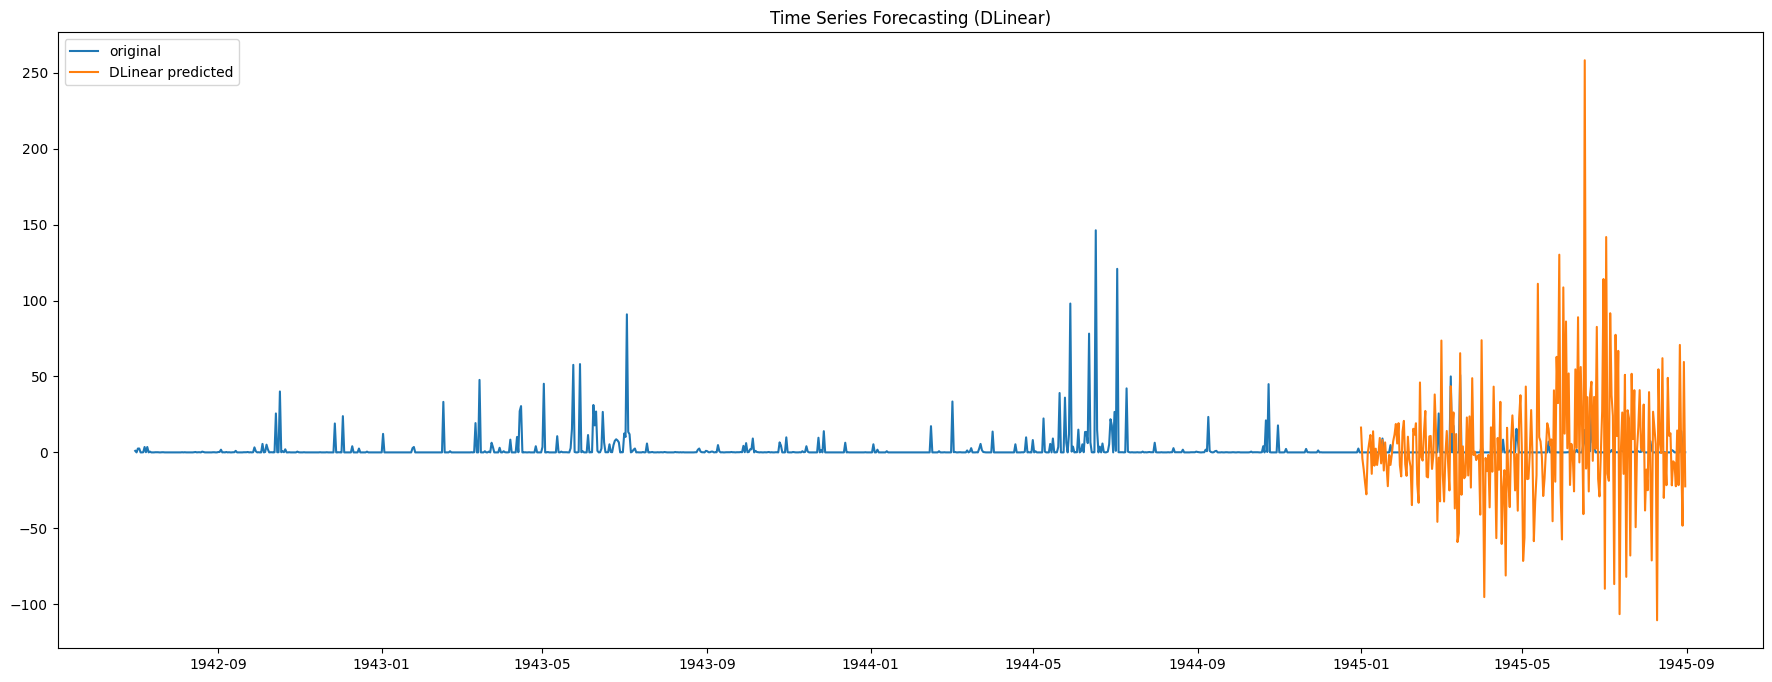

,R2,Corr,RMSE,MAPE
0,-5380.279,0.164,41.16,8.142876e+18


In [74]:
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.Precip, label="original")
plt.plot(test_ts.index, forecast_dl, label="DLinear predicted")
plt.title("Time Series Forecasting (DLinear)")
plt.legend()
plt.show()

scoring(
  np.array(weather_bin[weather_bin.Date >= start_index].Precip),
  forecast_dl.flatten()
)

### 추가 실험 결과 해석
"ARRCA"지역의 "강수량"에 대해 분석해보았다.
이전의 "AGRA" 지역에서 분석했던 "온도" 데이터와 달리 강한 스파이크가 있고, 데이터 특성상 0보다 큰 값들만 존재한다. ADF-Test에서 수차상으로는 단위근이 존재하지 않는는 결과가 나왔으나 시계열 도표를 보았으 때 정규성을 띠는 그래프의 형태로는 보이지 않는다. 주기성 또한 잘 보이지 않았고, 따라서 예측이 어려워 실제 ARIMA모형과 DLinear 모델 모두 성능이 좋지 않았다.